In [69]:
from time import time
import numpy as np
import tensorflow as tf
from tensorflow.keras import backend as K # type: ignore
from tensorflow.keras.layers import Layer, InputSpec, UpSampling2D, Flatten, Reshape, Conv2DTranspose  # type: ignore
from tensorflow.keras.models import Model  # type: ignore
from tensorflow.keras.initializers import VarianceScaling  # type: ignore
from sklearn.cluster import KMeans
from sklearn.cluster import MiniBatchKMeans
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn import metrics
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

## `TP Deep Clustering` 

L'objectif de ce TP consiste à créer un modèle constitué de plusieurs parties :

- Un auto-codeur, pré-entraîné pour apprendre la représentation condensée initiale des jeux de données non étiquetés.
- Une couche de clustering empilée sur l'encodeur pour affecter la sortie de l'encodeur à un cluster. Les poids de la couche de clustering sont initialisés avec les centres de cluster de K-Means basés sur l'évaluation actuelle.
- Entraîner le modèle de clustering pour affiner la couche de clustering et le codeur conjointement.


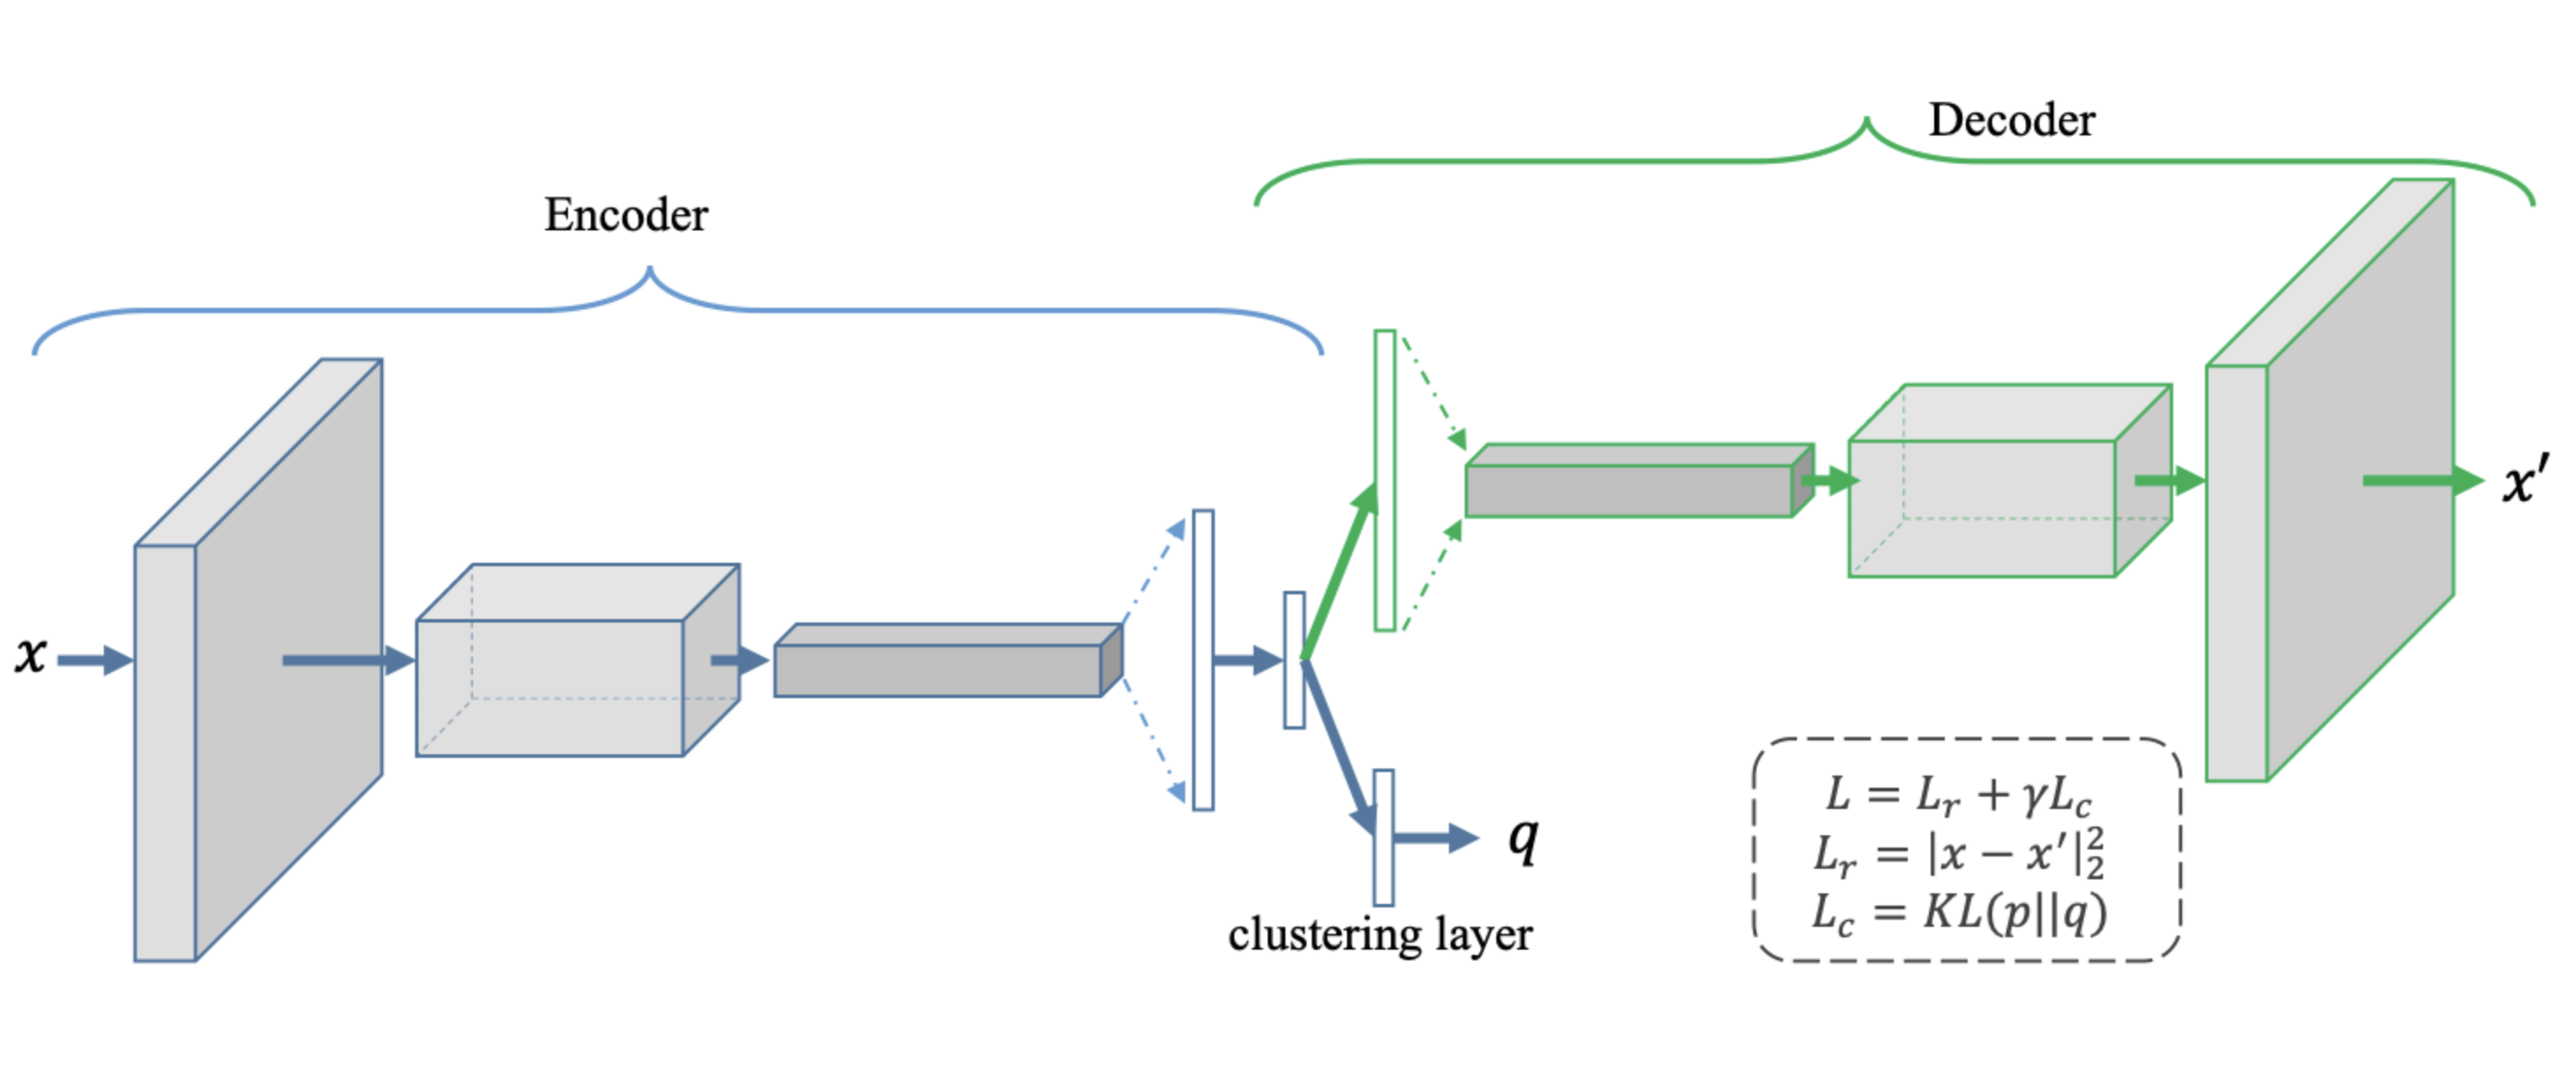

In [71]:
from IPython.display import Image, display # type: ignore
display(Image("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/2026_TP2_DeepClustering/images/DeepClustering.png",width=700))

`L’encoder + k‑means en non supervisé :`
 - Pipeline non supervisé encoder + k‑means
 - Pré‑entraînement non supervisé de l’encoder

`Autoencoder conv :` 
 - apprend à reconstruire l’image, donc l’espace latent z se structure sans labels.
 - Ou méthode type DEC / Deep Embedded K‑Means où l’encoder est entraîné avec une loss qui dépend des clusters eux‑mêmes (distribution cible, KL, etc.).

`Clustering dans l'espace latent`
 - on passe les images dans l’encoder, 
 - récupères les embeddings $z_i$, 
 - on appliques k‑means sur les ${z_i}$.

`Les indices de clusters de k‑means sont tes pseudo‑labels non supervisés`.
- Option raffinement (deep embedded clustering)
 - On ré‑entraînes l’encoder en forçant les embeddings à se rapprocher des centres de leurs clusters (loss basée sur la KL entre assignations et une distribution cible plus « piquée »).

Les seules « étiquettes » sont produites par k‑means à partir des features apprises, pas par un annotateur humain.

In [72]:
import tensorflow as tf

print("GPUs:", tf.config.list_physical_devices("GPU"))
print("TF version:", tf.__version__)

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TF version: 2.14.1


### `Chargement des données`

In [82]:
from keras.datasets import mnist  # type: ignore
from keras.datasets import fashion_mnist  # type: ignore à tester, + complexe que l'ensemble mnist 

import numpy as np

# Chargement et normalisation (entre 0 et 1) des données de la base de données MNIST/Fashion mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(f"x_train.shape : {x_train.shape}")
x_trainIm = x_train.astype('float32') / 255.
x_testIm = x_test.astype('float32') / 255.

print(f"x_trainIm.shape : {x_trainIm.shape}")
x_train_rshp = np.reshape(x_trainIm, (len(x_trainIm), 784))
x_test_rshp = np.reshape(x_testIm, (len(x_testIm), 784))

print(f"x_train_rshp.shape : {x_train_rshp.shape}")

x_train.shape : (60000, 28, 28)
x_trainIm.shape : (60000, 28, 28)
x_train_rshp.shape : (60000, 784)


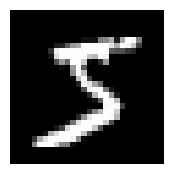

In [74]:
import matplotlib.pyplot as plt
plt.figure(figsize=(2,2))
plt.imshow(x_train[0], cmap='gray')
plt.axis('off')
plt.show()

### `Baseline par clustering classique par kmeans`

`y_pred_kmeans` 
- vecteur d’entiers de taille (n_samples,) 
- contient l’indice du cluster auquel KMeans a affecté chaque sample (0, 1, ..., n_clusters-1)
- il n’y a pas de correspondance directe entre indice de cluster et indice de classe. 
- les indices de KMeans sont arbitraires

In [83]:
# Nombre de classes à trouver
n_clusters=10
# nombre de chiffres
n_digits = len(np.unique(y_test))
print(f"n_digits : {n_digits}")
# Initialisation du Kmeans 
kmeans = MiniBatchKMeans(n_clusters = n_digits)

# Appliquer Kmeans sur base d'apprentissage
y_pred_kmeans = kmeans.fit_predict(x_train_rshp)
print(f"y_pred_kmeans.shape : {y_pred_kmeans.shape}")
print(f"y_pred_kmeans : {y_pred_kmeans}")

n_digits : 10
y_pred_kmeans.shape : (60000,)
y_pred_kmeans : [3 9 2 ... 3 3 3]


`Ecrire acc = accuracy_score(y_pred_kmeans, y_train) n’a pas de sens.`

Les options cohérentes sont donc :
 - remapping cluster → classe (via matrice de confusion + Hungarian) puis calculer l’accuracy;
 - utiliser des métriques de clustering (Adjusted Rand Index, NMI, etc.) plutôt qu’une accuracy.

In [84]:
# Score de performance
acc = accuracy_score(y_train,y_pred_kmeans)
print(f"Accuracy KMeans (fit_predict) : {acc:.4f}")

Accuracy KMeans (fit_predict) : 0.0583


### `Attribution des étiquettes de cluster`

 - La classification K-means est une méthode d'apprentissage automatique non supervisée
 - Les étiquettes KMeans référence la classification attribué à chaque élément et non à l'entier cible réel
 - Les fonctions ci-dessous permettent de prédir à quel classe correspond à chaque cluster

__`Ce que signifie cet appel`__
 - y_pred_kmeans (ou kmeans.labels_) sont les labels de clusters produits par KMeans.
 - y_train sont les vraies étiquettes (supervisées) de tes données d’entraînement.
 - `retrieve_info(cluster_labels, y_train)`
   - calcule, pour chaque cluster, la classe majoritaire dans ce cluster 
   - renvoie un tableau reference_labels qui fait la correspondance
   - reference_labels[i] = classe majoritaire parmi les points du cluster i.

In [85]:
def retrieve_info(cluster_labels, y_train):
    cluster_labels = np.asarray(cluster_labels).ravel()
    y_train = np.asarray(y_train).ravel()
    n_clusters = len(np.unique(cluster_labels))
    reference_labels = np.zeros(n_clusters, dtype=int)   # <-- 1D
    #print(f"cluster_labels : {cluster_labels.shape}")
    for i in range(n_clusters):
        index = (cluster_labels == i)
        num = np.bincount(y_train[index]).argmax()
        reference_labels[i] = num
    #print(f"index.shape : {index.shape}")    
    return reference_labels

- `La fonction correspondance effectue le mapping numéro de cluster classe réel`
- `Pour chaque prédiction cluster associé à un élement, la classe correspondante`

In [86]:
def correspondance(y_pred_kmeans,y_train):
  # y_pred_kmeans (ou kmeans.labels_) sont les labels de clusters produits par KMeans, 
  # reference_labels[i] = classe majoritaire parmi les points du cluster i.
  reference_labels = retrieve_info(y_pred_kmeans,y_train)
  number_labels = np.zeros(len(y_pred_kmeans))
  for i in range(len(y_pred_kmeans)):
    number_labels[i] = reference_labels[y_pred_kmeans[i]]
  return number_labels

`Obtenir un score de performance`
- Après la correspondance clusters → classes, 
- Utiliser _reference_labels_ pour transformer les labels de clusters en labels de classes, 
- puis calculer une accuracy classique.

In [87]:
# labels prédits (après correspondance cluster -> classe)
y_train_pred = correspondance(y_pred_kmeans, y_train)
print(f"y_train_pred.shape : {y_train_pred.shape}")

# score de performance sur l'apprentissage
score = accuracy_score(y_train, y_train_pred)
print(f"Accuracy KMeans (apprentissage) : {score:.4f}")

y_train_pred.shape : (60000,)
Accuracy KMeans (apprentissage) : 0.4826


In [88]:
# Affichage des données 
count=60000
ListeData = np.random.choice(len(y_train_pred), count)
inputs = x_train_rshp[ListeData]
classes = y_train[ListeData]
embedTSNE = TSNE(n_components=2).fit_transform(inputs)

In [89]:
import matplotlib.pyplot as plt

def display_2Dreduce(classes,embedTSNE=[] ,embedPCA=[], mode=("TSNE", "PCA")):
    """
    mode peut contenir :
      - ("TSNE", "PCA")  -> les deux graphiques côte à côte
      - ("TSNE",)        -> uniquement t-SNE
      - ("PCA",)         -> uniquement PCA
    """
    color = classes.astype(int)

    show_tsne = "TSNE" in mode
    show_pca  = "PCA" in mode

    if show_tsne and show_pca:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        ax = axes[0]
        sc = ax.scatter(embedTSNE[:, 0], embedTSNE[:, 1],c=color, cmap="Spectral", s=5, alpha=0.8)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title("MNIST en 2D par t-SNE", fontsize=8)
        fig.colorbar(sc, ax=ax)

        ax = axes[1]
        sc = ax.scatter(embedPCA[:, 0], embedPCA[:, 1],c=color, cmap="Spectral", s=5, alpha=0.8)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title("MNIST en 2D par PCA", fontsize=8)
        fig.colorbar(sc, ax=ax)

        plt.tight_layout()
        plt.show()

    elif show_tsne:
        fig, ax = plt.subplots(figsize=(6, 5))
        sc = ax.scatter(embedTSNE[:, 0], embedTSNE[:, 1],c=color, cmap="Spectral", s=5, alpha=0.8)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title("MNIST en 2D par t-SNE", fontsize=8)
        plt.colorbar(sc)
        plt.show()

    elif show_pca:
        fig, ax = plt.subplots(figsize=(6, 5))
        sc = ax.scatter(embedPCA[:, 0], embedPCA[:, 1],
                        c=color, cmap="Spectral", s=5, alpha=0.8)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title("MNIST en 2D par PCA", fontsize=8)
        plt.colorbar(sc)
        plt.show()


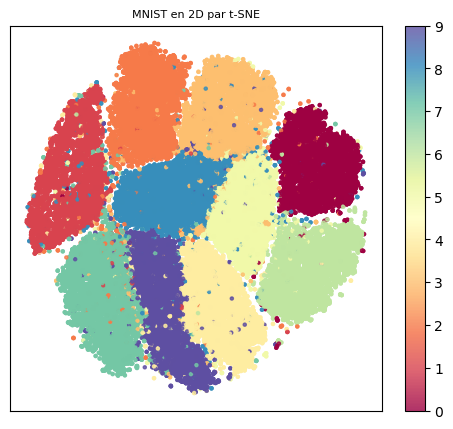

In [90]:
display_2Dreduce(classes,embedTSNE=embedTSNE, mode=("TSNE"))

### `1. Autoencodeur classique à définir`

In [91]:
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import Dense, Input #type: ignore

# Autoencodeur simple pour MNIST (28x28 -> 784)
autoencoder = Sequential([
    Input(shape=(784,)),          # image 28x28 aplatie
    Dense(128, activation="relu"),
    Dense(64, activation="relu",name="latent"), # couche "bottleneck"
    Dense(128, activation="relu"),
    Dense(784, activation="sigmoid")  # reconstruction 784, même taille que l'entrée
])

In [92]:

# encoder = input -> couche "latent"
x_in = autoencoder.input
z = autoencoder.get_layer("latent").output
encoder = Model(inputs=x_in, outputs=z, name="encoder")

# decoder = latent -> reconstruction (on repart de la couche après "latent")
z_in = Input(shape=(64,))
x = autoencoder.layers[-2](z_in)   # Dense(128, relu)
x_out = autoencoder.layers[-1](x)  # Dense(784, sigmoid)
decoder = Model(inputs=z_in, outputs=x_out, name="decoder")

### `2. AE + tête de classification supervisée`

In [ ]:


# encodeur(x) -> z
z_ae = encoder(x_in)
# reconstruction
x_rec = decoder(z_ae)
# tête de classif sur le latent
logits = Dense(10, activation="softmax", name="clf_head")(z_ae)
model_ae_clf = Model(inputs=x_in, outputs=[x_rec, logits], name="ae_plus_classifier")

model_ae_clf.compile(
    optimizer=Adam(1e-4),
    loss=["mse", "sparse_categorical_crossentropy"],
    loss_weights=[1.0, 0.1],
)

# x_train_flat : (60000, 784), y_train : (60000,)
model_ae_clf.fit(
    x_train_flat,
    [x_train_flat, y_train],
    batch_size=256,
    epochs=20,
    shuffle=True,
    validation_split=0.1,
)


In [18]:
autoencoder.compile(
    optimizer="adam",
    loss="mse",   
    metrics=["accuracy"],
)

### `Entraînement de l'autoencodeur` 

In [19]:
# Entraînement de l'autoencodeur 
history = autoencoder.fit(x_train_rshp, x_train_rshp,
                epochs=25,
                batch_size=128,
                shuffle=True,
                validation_data=(x_test_rshp, x_test_rshp))

Epoch 1/25


2026-02-21 20:53:57.140224: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


469/469 [==============================] - 5s 9ms/step - loss: 0.0409 - accuracy: 0.0106 - val_loss: 0.0240 - val_accuracy: 0.0084
Epoch 2/25
469/469 [==============================] - 4s 8ms/step - loss: 0.0810 - accuracy: 0.0125 - val_loss: 0.0989 - val_accuracy: 0.0097
Epoch 3/25
469/469 [==============================] - 3s 7ms/step - loss: 0.0981 - accuracy: 0.0159 - val_loss: 0.0958 - val_accuracy: 0.0139
Epoch 4/25
469/469 [==============================] - 3s 7ms/step - loss: 0.0941 - accuracy: 0.0168 - val_loss: 0.0928 - val_accuracy: 0.0174
Epoch 5/25
469/469 [==============================] - 3s 7ms/step - loss: 0.0927 - accuracy: 0.0169 - val_loss: 0.0923 - val_accuracy: 0.0149
Epoch 6/25
469/469 [==============================] - 3s 7ms/step - loss: 0.0911 - accuracy: 0.0148 - val_loss: 0.0907 - val_accuracy: 0.0081
Epoch 7/25
469/469 [==============================] - 3s 7ms/step - loss: 0.0895 - accuracy: 0.0167 - val_loss: 0.0888 - val_accuracy: 0.0164
Epoch 8/25
469/46

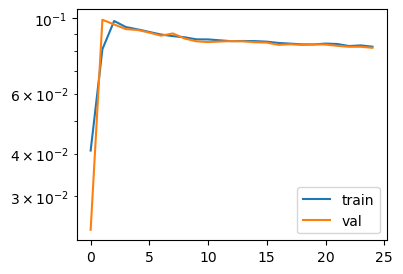

In [20]:
fig, ax = plt.subplots(figsize=(4, 3))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.legend(); plt.yscale("log")

In [21]:
autoencoder.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 128)               8320      
                                                                 
 dense_3 (Dense)             (None, 784)               101136    
                                                                 
Total params: 218192 (852.31 KB)
Trainable params: 218192 (852.31 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
# encoder = input -> couche "latent"
x_in = autoencoder.input
z = autoencoder.get_layer("latent").output
encoder = Model(inputs=x_in, outputs=z, name="encoder")

# decoder = latent -> reconstruction (on repart de la couche après "latent")
z_in = Input(shape=(64,))
x = autoencoder.layers[-2](z_in)   # Dense(128, relu)
x_out = autoencoder.layers[-1](x)  # Dense(784, sigmoid)
decoder = Model(inputs=z_in, outputs=x_out, name="decoder")

In [22]:
# Encoder et décoder quelques chiffres de l'ensemble test
from tensorflow.keras import Model, Input # type: ignore
# encoder = entrée -> couche bottleneck
_ = autoencoder(x_train_rshp[:1]) 

# 2) Récupérer l'input via la première couche
inp = Input(shape=(784,))
x = autoencoder.layers[0](inp)  # Dense(128)
code = autoencoder.layers[1](x)  # Dense(64)
encoder = Model(inp, code)

# decoder : code latent -> reconstruction
latent_input = Input(shape=(64,))
x = autoencoder.layers[2](latent_input)   # Dense(128)
decoded_output = autoencoder.layers[3](x) # Dense(784)
decoder = Model(latent_input, decoded_output)

1/1 [==============================] - 0s 31ms/step


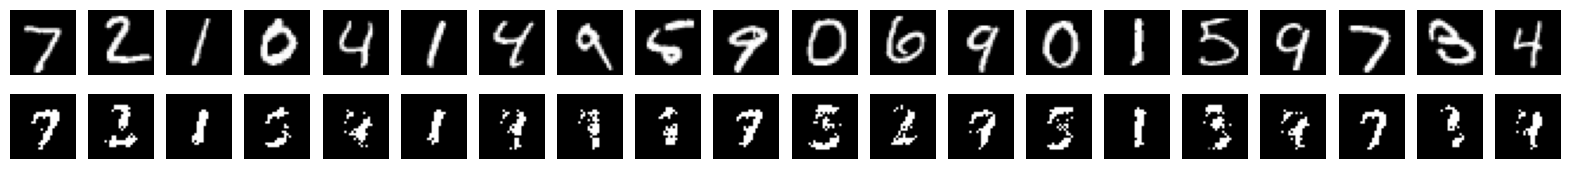

In [23]:
n = 20  # Combien de chiffres nous allons afficher
# Afficher l'image reconstruite à partir de l'espace latent après entraînement
# encoder / decoder
encoded_imgs = encoder.predict(x_test_rshp[:n])
decoded_imgs = decoder.predict(encoded_imgs)

import matplotlib.pyplot as plt

plt.figure(figsize=(20, 2))
for i in range(n):
    # original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_rshp[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # reconstruit
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
plt.show()

1875/1875 [==============================] - 2s 1ms/step
encoded_imgs.shape : (60000, 64)


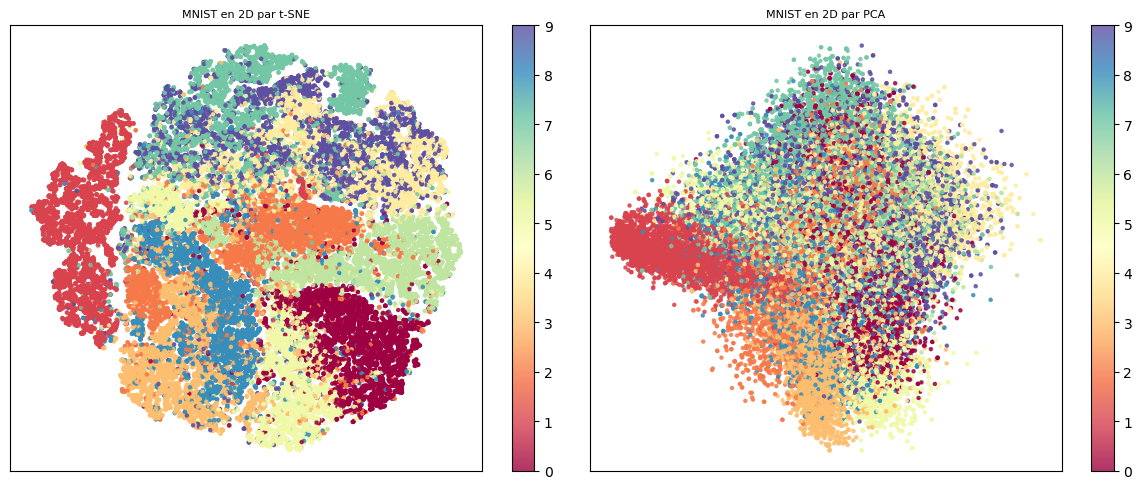

In [24]:
# Affichage de l'espace latent par réduction de dimension 
count=2000
inputs = x_train[ListeData]
x_trainIm = inputs.astype('float32') / 255
x_train_rshp = np.reshape(x_trainIm, (len(x_trainIm), 784))
classes = y_train[ListeData]
# Récupération des données dans l'espace latent
encoded_imgs = encoder.predict(x_train_rshp)
print(f"encoded_imgs.shape : {encoded_imgs.shape}")
# 1) Réduction de dimension 2D par ACP et affichage
embedPCA = PCA(n_components=2).fit_transform(encoded_imgs)
# 2) Réduction de dimension 2D avec t-SNE
embedTSNE = TSNE(n_components=2).fit_transform(encoded_imgs)
# Affichage de l'espace latent par réduction de dimension ACP vs t-SNE
display_2Dreduce(classes,embedTSNE ,embedPCA, mode=("TSNE", "PCA"))

1875/1875 [==============================] - 3s 2ms/step
Performance de l'autoencodeur : accuracy sur kmeans sur l'espace latent : : 0.5453


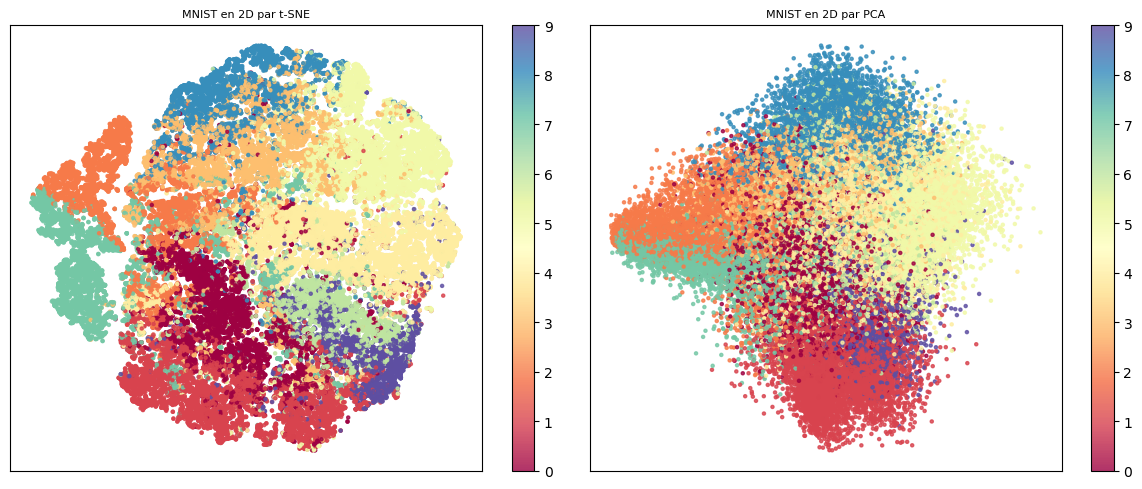

In [25]:
# Classification par kmeans de l'espace latent sur l'ensemble d'apprentissage
inputsTrain = x_train.astype('float32') / 255
inputsTrain_rshp = np.reshape(inputsTrain, (len(inputsTrain), 784))
classesTrain = y_train
# Récupération des données dans l'espace latent
encoded_allimgs = encoder.predict(inputsTrain_rshp)
# Initialisation du Kmeans 
kmeans = MiniBatchKMeans(n_clusters = n_digits)
# Appliquer Kmeans sur base d'apprentissage
y_pred_kmeans = kmeans.fit_predict(inputsTrain_rshp)
# labels prédits (après correspondance cluster -> classe)
y_train_pred = correspondance(y_pred_kmeans, y_train)
# Score de performance sur l'apprentissage
acc = accuracy_score(y_train_pred, classesTrain)
print(f"Performance de l'autoencodeur : accuracy sur kmeans sur l'espace latent : : {acc:.4f}")
# 2) Réduction de dimension 2D avec PCA
embedPCA = PCA(n_components=2).fit_transform(encoded_allimgs)
# 2) Réduction de dimension 2D avec t-SNE
embedTSNE = TSNE(n_components=2).fit_transform(encoded_allimgs)
# Affichage de l'espace latent par réduction de dimension ACP vs t-SNE
display_2Dreduce(y_pred_kmeans,embedTSNE ,embedPCA, mode=("TSNE", "PCA"))

## `Couche de Clustering` 
:::
`Deep Convolutional Embedded Clustering (DCEC), est une variante de DEC`.
 - Elle ajoute une couche de clustering au-dessus d’un autoencodeur convolutionnel, 
 - Elle précise les formules de $\textcolor{red}{q_{ij}}$, de la loss de clustering de la distribution cible $\textcolor{red}{p_{ij}}$.

`Couche de clustering et soft labels` $\large \textcolor{red}{q_{ij}}$
- Un encodeur $\large \textcolor{red}{f_θ}$ projette chaque image $\large \textcolor{red}{x_i}$ dans un espace latent $\large \textcolor{red}{z_i=f_θ(x_i)}$
 - La couche de clustering maintient des centres de clusters $\textcolor{red}{μ_j}$ (paramètres entraînables).
 - Pour chaque point latent $\textcolor{red}{z_i}$ et chaque centre $\textcolor{red}{μ_j}$, on calcule un soft label $\textcolor{red}{q_{ij}}$ via une distribution t de Student :

:::
:::
`Couche de Clustering Deep Embedded Clustering (DEC)`
`1.` Elle prend un vecteur de caractéristiques (la sortie de l'encodeur) 
`2.` Le transforme en probabilités d’appartenance aux clusters via une `distribution t de Student`.
`3.` La couche de clustering maintient les centres de cluster $\textcolor{red}{µ_j}$ comme poids entraînables 
`4.` Elle projette chaque point intégré $\textcolor{red}{z_i}$ en soft label $\textcolor{red}{q_i}$ par la distribution $t$ de Student 
`5.` Elle est utilisée comme noyau pour mesurer la similarité entre $\textcolor{red}{zi = fθ(x_i)}$ et le centroïd $\textcolor{red}{µ_j}$ :

$$\textcolor{red}{q_{ij}=\frac{(1+\|z_i-\mu_j\|^2)^{-1}}{\sum_j(1+\|z_i-\mu_j\|^2)^{-1}}}$$

 - $\textcolor{red}{q_{ij}}$ est la $\textcolor{red}{j^{ième}}$ entrée du vecteur $\textcolor{red}{q_i}$, représentant la probabilité d'appartenance de $\textcolor{red}{z_i}$ au cluster $\textcolor{red}{j}$
 - La normalisation au dénominateur fait que $\textcolor{red}{\sum_j q_{ij} = 1}$ pour chaque $\textcolor{red}{i}$
 $\textcolor{red}{\text{C’est exactement ce que fait la fonction ClusteringLayer ci-dessous }}$: 
- distances au carré, noyau __t__ de Student, puis normalisation par ligne.
 :::
 :::
 `La « t de Student »` 
  - C'est une distribution de probabilité, qui est utilisée comme noyau pour mesurer la similarité entre 
    - un point latent $\textcolor{red}{x_i}$ 
    - un centroïde $\textcolor{red}{u_j}$,
 $$\textcolor{red}{q_{ij} \propto \left( 1 + \frac{\lVert x_i - u_j \rVert^{2}}{\alpha} \right)^{\large -\frac{\alpha + 1}{2}}}$$
 - Puis on normalise sur $\textcolor{red}{j}$ pour obtenir une distribution de probabilité sur les clusters (soft labels)
 - Contrairement à `KMeans classique (hard labels)`, on obtient des assignations molles (soft assignments). 
 - Comme cette couche est différentiable et intégrée au réseau, on peut apprendre conjointement :
   - la représentation latente (l’encodeur),
   - les centres de clusters (self.clusters), en minimisant par exemple une Kullback–Leibler 
   - Cette `KL` s'effectue entre la distribution $\textcolor{red}{q}$ et la distribution cible $\textcolor{red}{p}$ (c’est DEC).
:::
:::
`KL, c’est la divergence de Kullback–Leibler souvent notée` $\textcolor{red}{D_{KL}}$ 
$$\textcolor{red}{D_{\text{KL}}(P \parallel Q)= \sum_{x \in X} P(x)\,\log \frac{P(x)}{Q(x)}}$$
 - Quantifie à quel point une distribution de probabilité $\textcolor{red}{Q}$ est différente d’une distribution «vraie» $\textcolor{red}{P}$
 - Considérons : 
    - $\textcolor{red}{P}$ soit la « vraie » loi des données 
    - $\textcolor{red}{Q}$ une approximation (modèle)
$\textcolor{red}{D_{KL}(P||Q)}$ mesure la perte d’information moyenne, si on encodait les données telles que : 
 - elles suivaient $\textcolor{red}{Q}$ alors qu’elles suivent en réalité $\textcolor{red}{P}$
 - si $\textcolor{red}{P = Q}$, la divergence est 0 (pas de perte).
 - plus $Q$ est différent de $\textcolor{red}{P}$ plus le $\textcolor{red}{KL}$ est grand.

__Perte de clustering $L_c$ = divergence KL entre P et Q__
 - On note $Q=(q_{ij})$ la distribution de soft labels produite par la couche de clustering.
 - On définit une distribution cible $P=(p_{ij})$
 - La loss de clustering est une divergence de Kullback–Leibler :
 $$\textcolor{red}{L_c = KL(P \parallel Q)= \sum_i \sum_j p_{ij} \log \frac{p_{ij}}{q_{ij}}}$$

 Avec les autoencodeurs / clustering profonds (comme DEC), on minimise souvent une KL entre une distribution cible P (par ex. labels « affinés ») et la distribution de clusters produite par le modèle Q
:::


:::
 - La couche de classification convertit l'échantillon d'entrée (caractéristique) en une étiquette souple
 - C'est-à-dire un vecteur qui représente la probabilité d'appartenance de l'échantillon à chaque groupe
 - Probabilité d'appartenance de l'échantillon à chaque cluster.
 - La probabilité est calculée avec la distribution t de student.        
:::
:::
`model.add(ClusteringLayer(n_clusters=10))`
- __n_clusters__ : nombre de clusters.
- __weights__ : liste de tableaux Numpy (n_clusters, n_features) qui représente les centres de clusters initiaux.
- __alpha__ : paramètre de la distribution t de Student. La valeur par défaut est 1.0.

`Forme de l'entrée` : Tenseur 2D avec la forme : __(n_samples, n_features)__
`Forme en sortie` : Tenseur 2D avec forme : __(n_samples, n_clusters)__
:::
:::

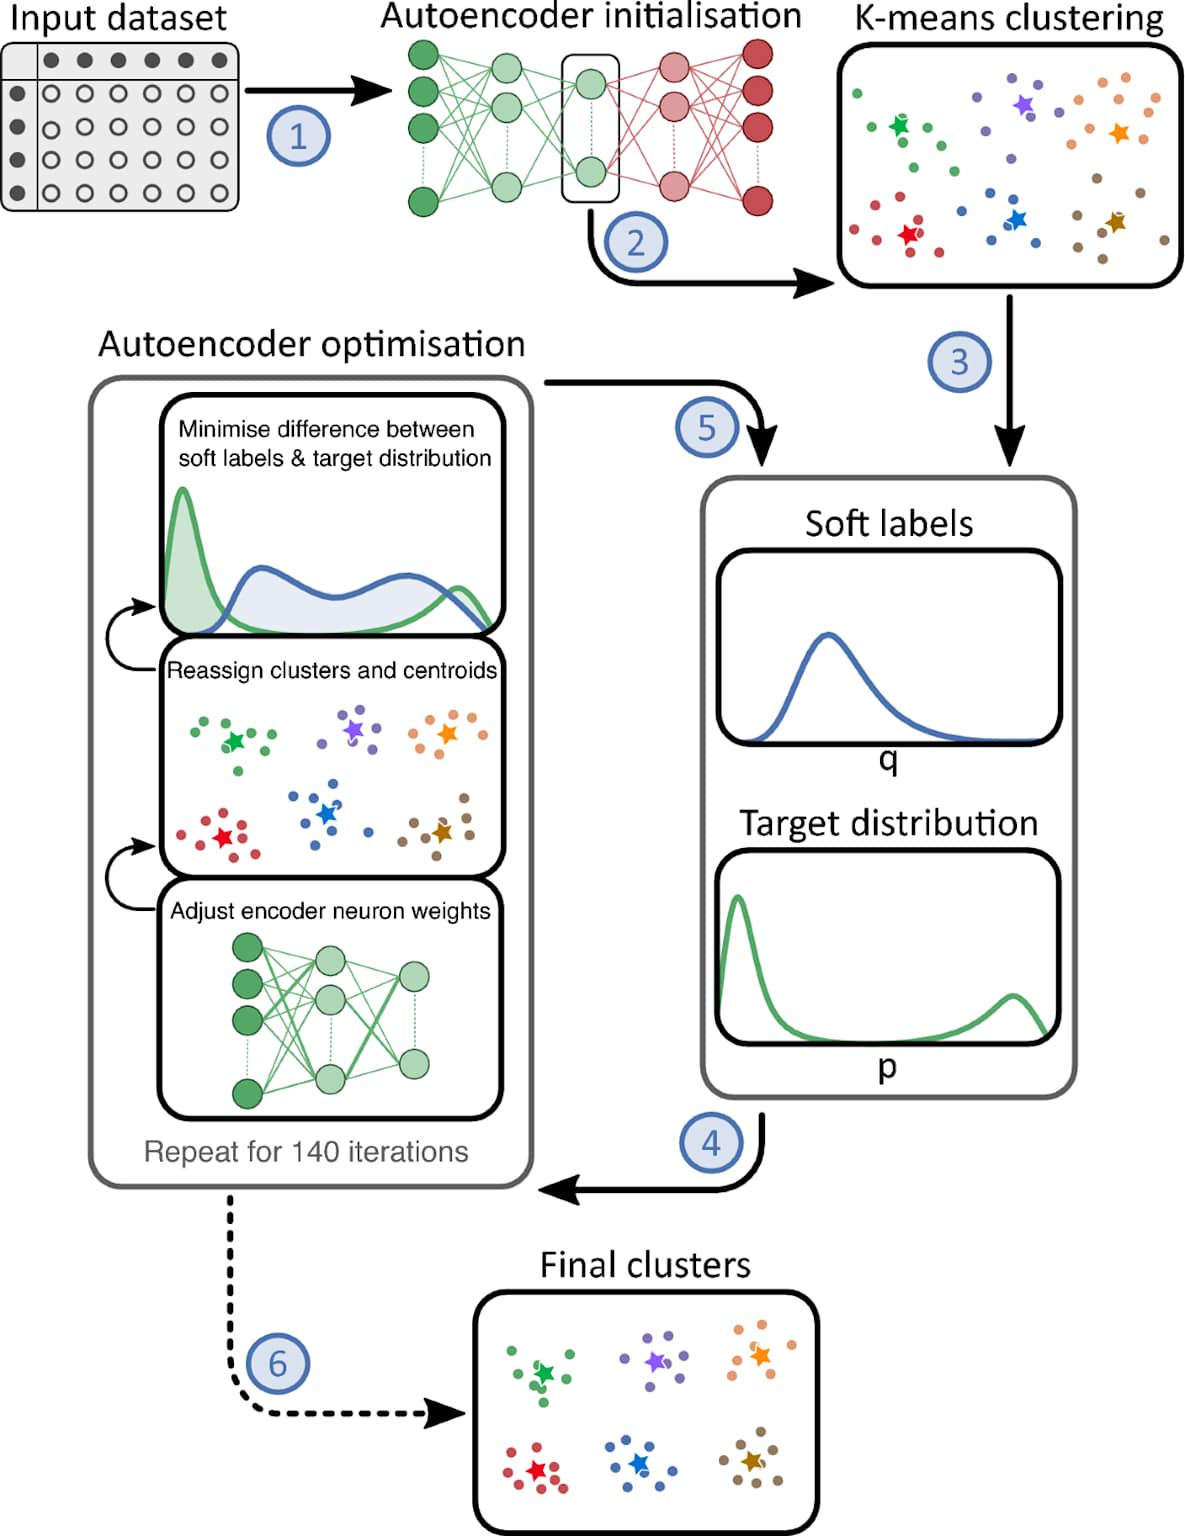

In [26]:
from IPython.display import Image, display
display(Image("M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/2026_TP2_DeepClustering/images/otoncdrKmnsClstrg.jpg",width=400))

In [27]:
class ClusteringLayer(Layer):

    def __init__(self, n_clusters, weights=None, alpha=1.0, **kwargs):
        if 'input_shape' not in kwargs and 'input_dim' in kwargs:
            kwargs['input_shape'] = (kwargs.pop('input_dim'),)
        super(ClusteringLayer, self).__init__(**kwargs)
        self.n_clusters = n_clusters
        self.alpha = alpha
        self.initial_weights = weights
        self.input_spec = InputSpec(ndim=2)

    def build(self, input_shape):
        assert len(input_shape) == 2
        input_dim = input_shape[1]
        self.input_spec = InputSpec(dtype=K.floatx(), shape=(None, input_dim))
        self.clusters = self.add_weight(shape=(self.n_clusters, input_dim), initializer='glorot_uniform', name='clusters')
        if self.initial_weights is not None:
            self.set_weights(self.initial_weights)
            del self.initial_weights
        self.built = True

    # Distribution t de student, la même que celle utilisée dans l'algorithme t-SNE.
    # q_ij = 1/(1+dist(x_i, u_j)^2), puis normalisation.
    # Arguments : inputs : la variable contenant les données, shape=(n_samples, n_features)
    # Retourne  : q la distribution t de student, ou des étiquettes souples pour chaque échantillon. shape=(n_samples, n_clusters)


    def call(self, inputs, **kwargs):
      # distance au carré entre chaque point et chaque centroïde
        diff = tf.expand_dims(inputs, axis=1) - self.clusters
        dist_sq = tf.reduce_sum(tf.square(diff), axis=2)
        q = 1.0 / (1.0 + dist_sq / self.alpha)
        q **= (self.alpha + 1.0) / 2.0                  # noyau t de Student
        q = q / tf.reduce_sum(q, axis=1, keepdims=True) # normalisation par ligne
        return q

    def compute_output_shape(self, input_shape):
        assert input_shape and len(input_shape) == 2
        return input_shape[0], self.n_clusters

    def get_config(self):
        config = {'n_clusters': self.n_clusters}
        base_config = super(ClusteringLayer, self).get_config()
        return dict(list(base_config.items()) + list(config.items()))


:::
`Définition de la distribution P cible définie comme :` 
 - $\textcolor{red}{p_{ij}}$ est la $\textcolor{red}{j^{ième}}$ entrée de $\textcolor{red}{p_i}$ représentant la probabilité d'appartenance de la donnée $\textcolor{red}{i}$ la classe $\textcolor{red}{j}$
 - Dans DEC, la distribution cible  $\textcolor{red}{P=(p_{ij}})$ se calcule à partir de $\textcolor{red}{Q=(q_{ij}}$) (la sortie de ta ClusteringLayer) en renforçant les assignations confiantes.

`La formule standard est :` $\large \textcolor{red}{p_{ij}=\frac{q_{ij}^2/\sum_i q_{ij}}{\sum_j (q_{ij}^2/\sum_i q_{ij})}}$
:::

In [28]:
import numpy as np

def target_distribution(q):
    eps = 1e-8
    weight = q ** 2 / (q.sum(0) + eps)
    return (weight.T / (weight.sum(1) + eps)).T


In [29]:
print("GPUs:", tf.config.list_physical_devices("GPU"))

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### `Entrainement du modèle avec la couche de clustering`

In [ ]:
import itertools
stop
# --- hyperparamètres à tester ---
batch_sizes = [128, 256]
lrs = [1e-4, 5e-4, 1e-3]

n_samples = x_train_rshp.shape[0]

results = []

for batch_size in batch_sizes:
    for lr in lrs:
        # update_interval ≈ n_samples / batch_size
        update_interval = n_samples // batch_size

        print(f"\n=== Run: batch_size={batch_size}, lr={lr}, update_interval={update_interval} ===")

        # 1) Recréer un nouvel encodeur + clustering_layer + model_DEC (pour repartir propre)
        #    (à adapter à ton code : ici j'assume que 'encoder' est déjà défini/pré-entraîné)
        clustering_layer = ClusteringLayer(n_clusters, name='clustering')(encoder.output)
        model_DEC = Model(inputs=encoder.input, outputs=clustering_layer)

        # 2) Initialiser les centres avec K-means sur z (recalculé pour ce run)
        kmeans = KMeans(n_clusters=n_clusters, n_init=20)
        z = encoder.predict(x_train_rshp, verbose=0)
        y_pred = kmeans.fit_predict(z)
        model_DEC.get_layer(name='clustering').set_weights([kmeans.cluster_centers_])

        # 3) Compiler avec Adam(lr)
        opt = tf.keras.optimizers.Adam(learning_rate=lr)
        model_DEC.compile(optimizer=opt, loss='kld')

        # 4) Boucle d'entraînement DEC (version compacte, même logique que la tienne)
        maxiter = 5000  # par ex.
        index_array = np.arange(n_samples)
        index = 0
        tol = 0.005

        # init q, p, y_pred_last
        q = model_DEC.predict(x_train_rshp, verbose=0)
        p = target_distribution(q)
        y_pred_last = q.argmax(axis=1)

        loss_history = []

        for ite in range(maxiter):
            if ite % update_interval == 0:
                # update q et p sur tout l'ensemble
                q = model_DEC.predict(x_train_rshp, verbose=0)
                p = target_distribution(q)

                y_pred = q.argmax(axis=1)
                if y_train is not None:
                    y_tmp = correspondance(y_pred, y_train)
                    acc = accuracy_score(y_train, y_tmp)
                    print(f"Iter {ite}, acc={acc:.4f}, loss={loss_history[-1] if loss_history else 0:.4f}")

                # critère d'arrêt
                delta_label = np.mean(y_pred != y_pred_last)
                y_pred_last = y_pred.copy()
                if ite > 0 and delta_label < tol:
                    print(f"Convergence (delta_label={delta_label:.4f} < {tol})")
                    break

            # mini-batch
            idx = index_array[index * batch_size: min((index + 1) * batch_size, n_samples)]
            loss = model_DEC.train_on_batch(x=x_train_rshp[idx], y=p[idx])
            loss_history.append(float(loss))

            index = index + 1 if (index + 1) * batch_size <= n_samples else 0

        # 5) Sauvegarder quelques métriques pour comparer les runs
        q_final = model_DEC.predict(x_train_rshp, verbose=0)
        y_final = q_final.argmax(axis=1)
        acc_final = None
        if y_train is not None:
            y_final_corr = correspondance(y_final, y_train)
            acc_final = accuracy_score(y_train, y_final_corr)

        results.append({
            "batch_size": batch_size,
            "lr": lr,
            "update_interval": update_interval,
            "acc_final": acc_final,
            "min_loss": np.min(loss_history) if loss_history else None
        })

# Afficher le résumé des runs
for r in results:
    print(r)


In [60]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

inputs = x_train
print(len(x_train))
n_samples = len(inputs)
x_trainIm = inputs.astype('float32') / 255
x_train_rshp = np.reshape(x_trainIm, (len(x_trainIm), 784))
#x_trainrshp = np.asarray(x_trainrshp) 

60000


In [ ]:
import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices())
print(tf.config.list_physical_devices('GPU'))

In [ ]:
def run_dec(batch_size, lr, update_interval):
        print(f"\n=== Run: batch_size={batch_size}, lr={lr}, update_interval={update_interval} ===")
        # 1) Recréer un nouvel encodeur + clustering_layer + model_DEC (pour repartir propre)
        #    (à adapter à ton code : ici j'assume que 'encoder' est déjà défini/pré-entraîné)
        clustering_layer = ClusteringLayer(n_clusters, name='clustering')(encoder.output)
        model_DEC = Model(inputs=encoder.input, outputs=clustering_layer)

        # 2) Initialiser les centres avec K-means sur z (recalculé pour ce run)
        kmeans = KMeans(n_clusters=n_clusters, n_init=20)
        z = encoder.predict(x_train_rshp, verbose=0)
        y_pred = kmeans.fit_predict(z)
        model_DEC.get_layer(name='clustering').set_weights([kmeans.cluster_centers_])

        # 3) Compiler avec Adam(lr)
        opt = tf.keras.optimizers.Adam(learning_rate=lr)
        model_DEC.compile(optimizer=opt, loss='kld')

        # 4) Boucle d'entraînement DEC (version compacte, même logique que la tienne)
        maxiter = 5000  # par ex.
        index_array = np.arange(n_samples)
        index = 0
        tol = 0.005

        # init q, p, y_pred_last
        q = model_DEC.predict(x_train_rshp, verbose=0)
        p = target_distribution(q)
        y_pred_last = q.argmax(axis=1)

        loss_history = []

        for ite in range(maxiter):
            if ite % update_interval == 0:
                # update q et p sur tout l'ensemble
                q = model_DEC.predict(x_train_rshp, verbose=0)
                p = target_distribution(q)

                y_pred = q.argmax(axis=1)
                if y_train is not None:
                    y_tmp = correspondance(y_pred, y_train)
                    acc = accuracy_score(y_train, y_tmp)
                    print(f"Iter {ite}, acc={acc:.4f}, loss={loss_history[-1] if loss_history else 0:.4f}")

                # critère d'arrêt
                delta_label = np.mean(y_pred != y_pred_last)
                y_pred_last = y_pred.copy()
                if ite > 0 and delta_label < tol:
                    print(f"Convergence (delta_label={delta_label:.4f} < {tol})")
                    break

            # mini-batch
            idx = index_array[index * batch_size: min((index + 1) * batch_size, n_samples)]
            loss = model_DEC.train_on_batch(x=x_train_rshp[idx], y=p[idx])
            loss_history.append(float(loss))

            index = index + 1 if (index + 1) * batch_size <= n_samples else 0

        # 5) Sauvegarder quelques métriques pour comparer les runs
        q_final = model_DEC.predict(x_train_rshp, verbose=0)
        y_final = q_final.argmax(axis=1)
        acc_final = None
        if y_train is not None:
            y_final_corr = correspondance(y_final, y_train)
            acc_final = accuracy_score(y_train, y_final_corr)
        return acc_final

maxiter = 5000   # debug
param_grid = {
    "batch_size": [64,128,256],
    "lr": [1e-4, 5e-4, 1e-3],
}

best_score = -np.inf
best_params = None
n_samples = x_train_rshp.shape[0]
print(n_samples)

for batch_size in param_grid["batch_size"]:
    for lr in param_grid["lr"]:
        update_interval = n_samples // batch_size
        score = run_dec(batch_size, lr, update_interval)
        print(batch_size, lr, update_interval, "->", score)
        if score > best_score: # type: ignore
            best_score = score
            best_params = (batch_size, lr, update_interval)

print("Best:", best_params, "score=", best_score)


60000

=== Run: batch_size=128, lr=0.0001, update_interval=468 ===


Iter 0, acc=0.4173, loss=0.0000


2026-02-21 21:20:34.252201: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


Iter 468, acc=0.4123, loss=0.1070
Iter 936, acc=0.4059, loss=0.1253
Iter 1404, acc=0.4015, loss=0.1137
Iter 1872, acc=0.3942, loss=0.0971
Iter 2340, acc=0.3857, loss=0.1081
Iter 2808, acc=0.3755, loss=0.1316
Iter 3276, acc=0.3667, loss=0.1291
Iter 3744, acc=0.3574, loss=0.1199
Iter 4212, acc=0.3488, loss=0.1148
Iter 4680, acc=0.3413, loss=0.1417
128 0.0001 468 -> 0.3345666666666667

=== Run: batch_size=128, lr=0.0005, update_interval=468 ===


Iter 0, acc=0.3404, loss=0.0000


2026-02-21 21:22:16.299492: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


Iter 468, acc=0.3230, loss=0.1971
Iter 936, acc=0.3008, loss=0.1947
Iter 1404, acc=0.2996, loss=0.1608
Iter 1872, acc=0.2982, loss=0.1312
Iter 2340, acc=0.2979, loss=0.1468
Iter 2808, acc=0.2955, loss=0.1479
Iter 3276, acc=0.2925, loss=0.1392
Iter 3744, acc=0.2896, loss=0.1094
Iter 4212, acc=0.2874, loss=0.1100
Iter 4680, acc=0.2850, loss=0.1364
128 0.0005 468 -> 0.28275

=== Run: batch_size=128, lr=0.001, update_interval=468 ===


Iter 0, acc=0.2744, loss=0.0000


2026-02-21 21:23:59.478066: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


Iter 468, acc=0.2781, loss=0.2523
Iter 936, acc=0.2772, loss=0.2134
Iter 1404, acc=0.2757, loss=0.1793
Iter 1872, acc=0.2782, loss=0.1490
Iter 2340, acc=0.2783, loss=0.1538
Iter 2808, acc=0.2769, loss=0.1410
Iter 3276, acc=0.2751, loss=0.1352
Iter 3744, acc=0.2733, loss=0.1103
Iter 4212, acc=0.2723, loss=0.1097
Iter 4680, acc=0.2708, loss=0.1262
128 0.001 468 -> 0.2697
Best: (128, 0.0001, 468) score= 0.3345666666666667


In [62]:
# paramètres à fixer
loss = 0.0
index = 0

maxiter = 5000
batch_size = 128
update_interval = 500   # comme tu as

index_array = np.arange(x_train.shape[0])
tol = 0.01 # seuil pour critère d'arrêt

In [ ]:
# encodeur(x) -> z
z = encoder(x)

# reconstruction
x_rec = decoder(z)

# tête de classif sur le latent
logits = Dense(10, activation="softmax")(z)

model = Model(inputs=x, outputs=[x_rec, logits])
model.compile(
    optimizer=tf.keras.optimizers.legacy.Adam(1e-4),
    loss=["mse", "sparse_categorical_crossentropy"],
    loss_weights=[1.0, 0.1],   # pondérer recon vs. séparabilité de classes
)
model.fit(x_train, [x_train, y_train], ...)


In [ ]:
# 0) Initialisation de K-means
kmeans = KMeans(n_clusters=n_clusters, n_init=20)
# 1) K-means dans l’espace latent
z = encoder.predict(x_train_rshp)
y_pred= kmeans.fit_predict(z)
y_pred_last = np.copy(y_pred)
# 2) Modèle DEC : encodeur + couche de clustering
clustering_layer = ClusteringLayer(n_clusters, name='clustering')(encoder.output)
model_DEC = Model(inputs=encoder.input, outputs=clustering_layer)
# 3) Initialiser la couche de clustering avec les μ_j latents
μj = kmeans.cluster_centers_ # array NumPy (n_clusters, n_features) 
model_DEC.get_layer(name='clustering').set_weights([μj])
# 4) Compiler pour optimiser la KL (DEC)
opt = tf.keras.optimizers.Adam(learning_rate=1e-4)
model_DEC.compile(optimizer=opt, loss='kld')

1875/1875 [==============================] - 2s 1ms/step


`4. Lecture globale de ta boucle`
__Tous les update_interval itérations :__
 - on recalcule `Q`,
 - on ,construit `P`,
 - on évalue l’accuracy et la convergence (delta de labels).

__À chaque itération :__
- on prend un batch (x_batch, p_batch) → train_on_batch.

In [64]:
for ite in range(int(maxiter)):
    if ite % update_interval == 0:
        # projette chaque point intégré zi en soft label qi par la distribution $t$ de Student
        # calcule les soft labels qij pour tous les échantillons d’entraînement.
        q = model_DEC.predict(x_train_rshp, verbose=0)
        # p est la distribution cible définie comme
        p = target_distribution(q)  # mise à jour de la distribution cible p 

        # evaluation de la performance du clustering 
        # transforme les soft labels en labels de cluster « durs »
        # 1 indique l’axe sur lequel on prend le max, ici l’axe des colonnes
        y_pred = q.argmax(axis=1)
        if y_train is not None: 
            # La fonction correspondance effectue le mapping numéro de cluster classe réel
            y_pred=correspondance(y_pred,y_train)
            acc = np.round(accuracy_score(y_train, y_pred), 5)
            loss = np.round(loss, 5)
            print('(Iter , acc)  ',(ite, acc), ' ; loss=', loss)

        # check stop criterion - model convergence
        delta_label = np.sum(y_pred != y_pred_last).astype(np.float32) / y_pred.shape[0]
        y_pred_last = np.copy(y_pred)
        if ite > 0 and delta_label < tol:
            print('delta_label ', delta_label, '< tol ', tol)
            print('Reached tolerance threshold. Stopping training.')
            break
  
    idx = index_array[index * batch_size: min((index+1) * batch_size, x_train_rshp.shape[0])]
    loss = model_DEC.train_on_batch(x=x_train_rshp[idx], y=p[idx])
    index = index + 1 if (index + 1) * batch_size <= x_train_rshp.shape[0] else 0

(Iter , acc)   (0, 0.27508)  ; loss= 0.0


2026-02-21 21:31:43.663334: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


(Iter , acc)   (500, 0.27518)  ; loss= 0.16198
(Iter , acc)   (1000, 0.27635)  ; loss= 0.17385
(Iter , acc)   (1500, 0.27598)  ; loss= 0.17647
(Iter , acc)   (2000, 0.27487)  ; loss= 0.16731
(Iter , acc)   (2500, 0.27595)  ; loss= 0.17988
(Iter , acc)   (3000, 0.2767)  ; loss= 0.17013
(Iter , acc)   (3500, 0.27687)  ; loss= 0.17555
(Iter , acc)   (4000, 0.27693)  ; loss= 0.16818
(Iter , acc)   (4500, 0.27707)  ; loss= 0.17947


`1. Autoencodeur initial`
D’abord un autoencodeur pré‑entraîné :
- encoder: $x ↦ z$ (espace latent)
- decoder: $z ↦ \hat{x}$
- autoencoder: $x ↦ \hat{x}$
Après pré‑entraînement, les poids de encoder sont fixés, on va les réutiliser dans DEC.
`2. Modèle DEC :` 
 - `model = Model(inputs=encoder.input, outputs=clustering_layer)`
 - x → encoder → z → ClusteringLayer → q
`3. Pendant l’entraînement DEC :`
 - mise à jour des poids de l’encodeur + les centroïdes $μ_j$ dans ClusteringLayer 
`4. Encoder entraîné`
Après entraînement DEC, on veut récupérer le nouvel espace latent z (encodeur affiné). 
_Deux options :_
- on réutilise directement encoder (ses poids ont été modifiés par DEC, car ils sont partagés).
- on construit une vue explicite `encoder_trained = Model(inputs=model.input,outputs=encoder.output)`


313/313 [==============================] - 0s 1ms/step


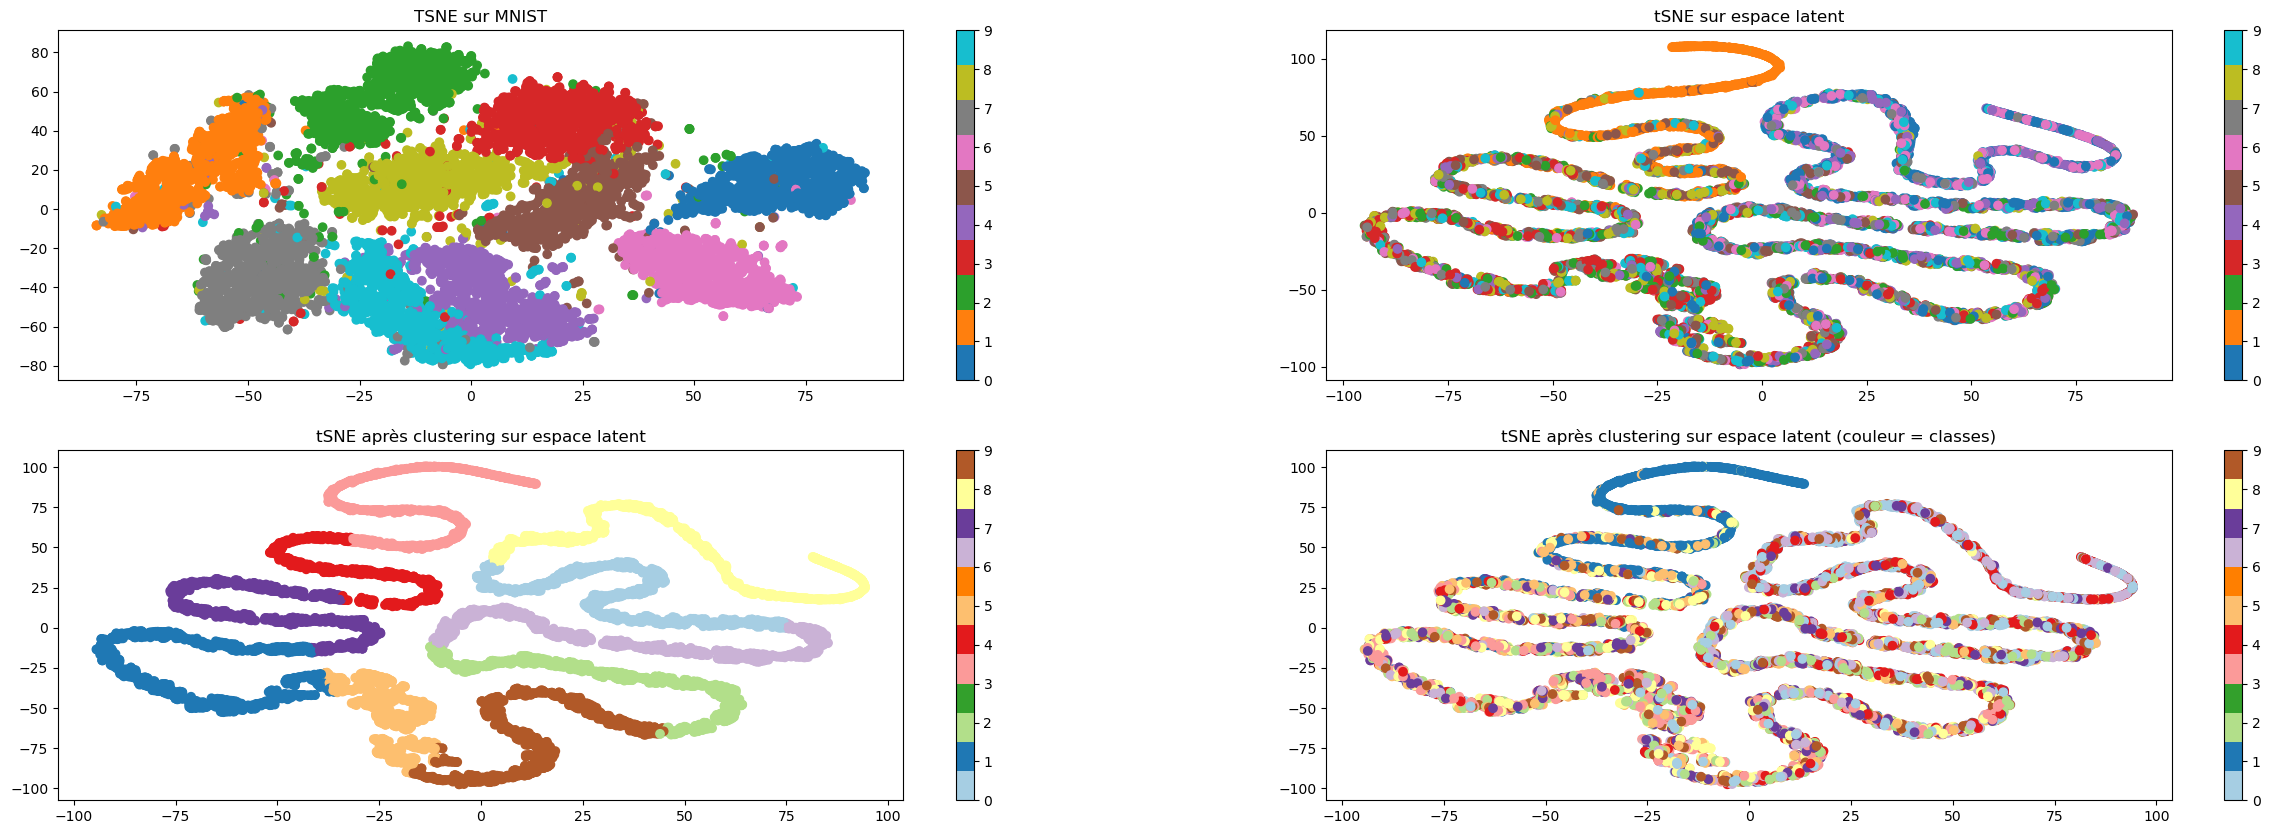

In [66]:
# Affichage de l'impact de cette couche clustering 
inputs = x_test
classes = y_test

x_testIm = inputs.astype('float32') / 255
x_test_rshp = np.reshape(x_testIm, (len(x_testIm), 784))

# TSNE sur MNIST
coordsTSNE_MNIST = TSNE(n_components=2).fit_transform(x_test_rshp)

fig2= plt.figure(figsize=(30, 10))
ax2=plt.subplot(2,2,1)
ax2.set_title("TSNE sur MNIST")
plt.scatter(coordsTSNE_MNIST[:, 0], coordsTSNE_MNIST[:, 1], c=classes, cmap='tab10')
plt.colorbar()

# TSNE sur espace latent
z_before = encoder.predict(x_test_rshp)
coordsTSNE_before = TSNE(n_components=2).fit_transform(z_before)

ax2 = plt.subplot(2,2,2)
ax2.set_title("tSNE sur espace latent")
plt.scatter(coordsTSNE_before[:, 0], coordsTSNE_before[:, 1], c=classes, cmap='tab10')
plt.colorbar()

# TSNE sur espace latent avec kmeans
encoder_trained = Model(inputs=model_DEC.input,outputs=encoder.output)
z_after = encoder_trained.predict(x_test_rshp, verbose=0)
coordsTSNE_trained = TSNE(n_components=2).fit_transform(z_after)

# q_test = soft assignments DEC pour ton sous‑ensemble
q_test = model_DEC.predict(x_test_rshp, verbose=0) # q_test a shape (n_samples, n_clusters)
# y_pred_dec = clusters DEC « durs » (indices de clusters).
y_pred_dec = q_test.argmax(axis=1) # Clusters obtenus par DEC après optimisation de KL(P|Q).

ax2 = plt.subplot(2,2,3)
ax2.set_title("tSNE après clustering sur espace latent")
plt.scatter(coordsTSNE_trained[:, 0], coordsTSNE_trained[:, 1], c=y_pred_dec,cmap='Paired')
plt.colorbar()

ax2 = plt.subplot(2,2,4)
ax2.set_title("tSNE après clustering sur espace latent (couleur = classes)")
plt.scatter(coordsTSNE_trained[:, 0], coordsTSNE_trained[:, 1], c=classes,cmap='Paired')
plt.colorbar()


__`En résumé, visuellement c’est très propre`__ : 
 - On voit bien la transition “clusters d’images → manifold latent continu → segmentation du manifold par K‑means”, 
 - Cela raconte exactement l’histoire qu’on aimerait voir pour ce type d’expérience.

`En haut à gauche, le t‑SNE sur les images MNIST brutes` 
 - conserve une bonne séparation, mais avec des clusters encore un peu brouillons (chevauchement 4–9, 3–5, etc.).

`En haut à droite, le t‑SNE de l’espace latent` 
- Est clairement “enroulé” sur une sorte de manifold 1D continu
- Les classes sont mélangées le long du ruban, ce qui est typique d’un autoencodeur non supervisé qui code surtout la continuité des formes plutôt que la classe.

`En bas à gauche, le t‑SNE après clustering sur le latent` 
 - Montre que K‑means a parfaitement suivi le ruban et produit des segments bien nets, 
 - Ceci veut dire que la structure intrinsèque est très régulière.

`En bas à droite, le t‑SNE après clustering sur le latent par classes` 
 - Montre que certains segments du ruban sont dominés par une classe (bonne correspondance cluster↔classe), 
 - Alors que d’autres restent mixtes, ce qui reflète bien les limites du signal purement non supervisé.

__`Points positifs`__
 - L’espace latent est extrêmement régulier (une belle courbe continue), 
 - signe que l'encodeur capture une variable de “style/forme” principale, 
 - Ceci est intéressant pour de la manipulation des données depuis l'espace latent.
 - Le clustering sur cet espace marche très bien géométriquement (clusters compacts, frontières nettes), 
 - Donc le pipeline d’autoencodeur + K‑means est cohérent.

Ce que j’affinerais
Pour un objectif réellement “classif MNIST”, tu gagnerais sans doute à ajouter un petit head supervisé ou une régularisation de type DEC / IDEC (loss de clustering jointe) pour forcer une meilleure séparation de classes le long du ruban.

Tu peux aussi regarder la courbe “latent 1D vs label” (par ex. PCA 1D du latent) pour voir dans quel ordre les classes s’alignent; ça t’aidera à interpréter les morceaux du ruban.





### `Passer à la version convolutive de l'autoencodeur`

_Détaillons les blocs :_
  1. Input(shape = (28, 28, 1))
2. Conv2D(32, ...)
3. MaxPooling2D((2, 2), ...)
4. Conv2D(64, ...)
5. MaxPooling2D((2, 2), ...) ← sortie typique de l’encodeur (bottleneck)
6. Conv2D(64, ...)
7. UpSampling2D(...)
8. Conv2D(32, ...)
9. UpSampling2D(...)
10. Conv2D(1, ...) (sortie décodée 28×28×1)

In [ ]:
from tensorflow.keras.models import Sequential # type: ignore 
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D  # type: ignore
 
autoencoder = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2), padding="same"),
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2), padding="same"),
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    UpSampling2D((2, 2)),
    Conv2D(32, (3, 3), activation="relu", padding="same"),
    UpSampling2D((2, 2)),
    Conv2D(1, (3, 3), activation="sigmoid", padding="same")  # sortie 28x28x1
])

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(x_train.shape)
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test  = np.reshape(x_test,  (len(x_test), 28, 28, 1))

In [ ]:
autoencoder.compile(
    optimizer="adam",
    loss="mse",   
    metrics=["accuracy"],
)
# Entraînement de l'autoencodeur 
history = autoencoder.fit(x_train, x_train,
                epochs=25,
                batch_size=128,
                shuffle=True,
                validation_data=(x_test, x_test))

# Encoder et décoder quelques chiffres de l'ensemble test
from tensorflow.keras import Model, Input # type: ignore
# encoder = entrée -> couche bottleneck
_ = autoencoder(x_train[:1]) 

encoder = Model(
    inputs=autoencoder.input,
    outputs=autoencoder.layers[5].output  # couche bottleneck
)
# 1) Récupérer la forme de la couche bottleneck
bottleneck_shape = autoencoder.layers[5].output_shape[1:]  # ex: (7, 7, 64)
# 2) Entrée latent de même forme
latent_input = Input(shape=bottleneck_shape)
# 3) Appliquer les couches de décodage (6 à la fin) sur cette entrée
x = latent_input
for layer in autoencoder.layers[6:]:
    x = layer(x)

decoder = Model(latent_input, x)

In [ ]:
# 0) Initialisation de K-means
kmeans = KMeans(n_clusters=n_clusters, n_init=20)
# 1) K-means dans l’espace latent
z = encoder.predict(x_train_rshp)
y_pred= kmeans.fit_predict(z)
y_pred_last = np.copy(y_pred)
# 2) Modèle DEC : encodeur + couche de clustering
clustering_layer = ClusteringLayer(n_clusters, name='clustering')(encoder.output)
model_DEC = Model(inputs=encoder.input, outputs=clustering_layer)
# 3) Initialiser la couche de clustering avec les μ_j latents
μj = kmeans.cluster_centers_ # array NumPy (n_clusters, n_features) 
model_DEC.get_layer(name='clustering').set_weights([μj])
# 4) Compiler pour optimiser la KL (DEC)
model_DEC.compile(optimizer="Adam", loss='kld')

In [ ]:
for ite in range(int(maxiter)):
    if ite % update_interval == 0:
        # projette chaque point intégré zi en soft label qi par la distribution $t$ de Student
        # calcule les soft labels qij pour tous les échantillons d’entraînement.
        q = model_DEC.predict(x_train_rshp, verbose=0)
        # p est la distribution cible définie comme
        p = target_distribution(q)  # mise à jour de la distribution cible p 

        # evaluation de la performance du clustering 
        # transforme les soft labels en labels de cluster « durs »
        # 1 indique l’axe sur lequel on prend le max, ici l’axe des colonnes
        y_pred = q.argmax(axis=1)
        if y_train is not None: 
            # La fonction correspondance effectue le mapping numéro de cluster classe réel
            y_pred=correspondance(y_pred,y_train)
            acc = np.round(accuracy_score(y_train, y_pred), 5)
            loss = np.round(loss, 5)
            print('(Iter , acc)  ',(ite, acc), ' ; loss=', loss)

        # check stop criterion - model convergence
        delta_label = np.sum(y_pred != y_pred_last).astype(np.float32) / y_pred.shape[0]
        y_pred_last = np.copy(y_pred)
        if ite > 0 and delta_label < tol:
            print('delta_label ', delta_label, '< tol ', tol)
            print('Reached tolerance threshold. Stopping training.')
            break
  
    idx = index_array[index * batch_size: min((index+1) * batch_size, x_train_rshp.shape[0])]
    loss = model_DEC.train_on_batch(x=x_train_rshp[idx], y=p[idx])
    index = index + 1 if (index + 1) * batch_size <= x_train_rshp.shape[0] else 0

In [ ]:
# Affichage de l'impact de cette couche clustering 
inputs = x_test[ListeData]
classes = y_test[ListeData]

x_testIm = inputs.astype('float32') / 255
x_test_rshp = np.reshape(x_testIm, (len(x_testIm), 784))

# TSNE sur MNIST
coordsTSNE_MNIST = TSNE(n_components=2).fit_transform(x_test_rshp)

fig2= plt.figure(figsize=(30, 10))
ax2=plt.subplot(2,2,1)
ax2.set_title("TSNE sur MNIST")
plt.scatter(coordsTSNE_MNIST[:, 0], coordsTSNE_MNIST[:, 1], c=classes, cmap='tab10')
plt.colorbar()

# TSNE sur espace latent
z_before = encoder.predict(x_test_rshp)
coordsTSNE_before = TSNE(n_components=2).fit_transform(z_before)

ax2 = plt.subplot(2,2,2)
ax2.set_title("tSNE sur espace latent")
plt.scatter(coordsTSNE_before[:, 0], coordsTSNE_before[:, 1], c=classes, cmap='tab10')
plt.colorbar()

# TSNE sur espace latent avec kmeans
encoder_trained = Model(inputs=model_DEC.input,outputs=encoder.output)
z_after = encoder_trained.predict(x_test_rshp, verbose=0)
coordsTSNE_trained = TSNE(n_components=2).fit_transform(z_after)

# q_test = soft assignments DEC pour ton sous‑ensemble
q_test = model_DEC.predict(x_test_rshp, verbose=0) # q_test a shape (n_samples, n_clusters)
# y_pred_dec = clusters DEC « durs » (indices de clusters).
y_pred_dec = q_test.argmax(axis=1) # Clusters obtenus par DEC après optimisation de KL(P|Q).

ax2 = plt.subplot(2,2,3)
ax2.set_title("tSNE après clustering sur espace latent")
plt.scatter(coordsTSNE_trained[:, 0], coordsTSNE_trained[:, 1], c=y_pred_dec,cmap='Paired')
plt.colorbar()

ax2 = plt.subplot(2,2,4)
ax2.set_title("tSNE après clustering sur espace latent (couleur = classes)")
plt.scatter(coordsTSNE_trained[:, 0], coordsTSNE_trained[:, 1], c=classes,cmap='Paired')
plt.colorbar()
